In [1]:
!pip -q install transformers sentencepiece librosa open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 63.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,

In [2]:
import os
import random
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import librosa

import torch
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModel,
    Wav2Vec2Processor,
    Wav2Vec2Model
)

import open_clip

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("DEVICE =", DEVICE)

DEVICE = cuda


In [4]:
DATASET_PATH = "/kaggle/input/datasets/ajfaisal002/crossmodal-misleading-video-dataset"

TRAIN_FRAMES = os.path.join(
    DATASET_PATH,
    "dataset_kaggle/extracted_frames/train"
)

TEST_FRAMES = os.path.join(
    DATASET_PATH,
    "dataset_kaggle/extracted_frames/test"
)

TRAIN_AUDIO = os.path.join(
    DATASET_PATH,
    "extracted_audio/extracted_audio/train"
)

TEST_AUDIO = os.path.join(
    DATASET_PATH,
    "extracted_audio/extracted_audio/test"
)

TRAIN_META = os.path.join(
    DATASET_PATH,
    "dataset_kaggle/extracted_text/train_metadata.csv"
)

TEST_META = os.path.join(
    DATASET_PATH,
    "dataset_kaggle/extracted_text/test_metadata.csv"
)


train_df = pd.read_csv(TRAIN_META)
test_df = pd.read_csv(TEST_META)

for df in [train_df, test_df]:

    df["transcript"] = df["transcript"].fillna("")
    df["ocr_text"] = df["ocr_text"].fillna("")

    df["full_text"] = (
        df["transcript"] + " " + df["ocr_text"]
    )

train_df["label_binary"] = (
    train_df["category"] == "misleading"
).astype(int)

test_df["label_binary"] = (
    test_df["category"] == "misleading"
).astype(int)

In [5]:
STAGE2_CLASSES = [
    "identity_fabrication",
    "perception_manipulation",
    "scientifically_unrealistic_scene",
    "surreal_content"
]

stage2_map = {
    c:i
    for i,c in enumerate(STAGE2_CLASSES)
}

def stage2_label(x):

    if pd.isna(x):
        return -1

    return stage2_map[x]

train_df["label_stage2"] = (
    train_df["subcategory"]
    .apply(stage2_label)
)

test_df["label_stage2"] = (
    test_df["subcategory"]
    .apply(stage2_label)
)

In [6]:
all_classes = [
    "safe",
    "identity_fabrication",
    "perception_manipulation",
    "scientifically_unrealistic_scene",
    "surreal_content"
]

five_map = {
    c:i
    for i,c in enumerate(all_classes)
}

In [7]:
def make_5class(row):

    if row["category"]=="safe":
        return 0

    return five_map[row["subcategory"]]

train_df["label_5class"] = (
    train_df.apply(make_5class,axis=1)
)

test_df["label_5class"] = (
    test_df.apply(make_5class,axis=1)
)

In [8]:
train_df,val_df = train_test_split(

    train_df,

    test_size=0.15,

    stratify=train_df["label_5class"],

    random_state=SEED
)

In [9]:
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32",
    pretrained="openai"
)

clip_model = clip_model.to(DEVICE)
clip_model.eval()

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [10]:
tokenizer = AutoTokenizer.from_pretrained(
    "xlm-roberta-base"
)

text_model = AutoModel.from_pretrained(
    "xlm-roberta-base"
)

text_model = text_model.to(DEVICE)
text_model.eval()

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: xlm-roberta-base
Key                       | Status     |  | 
--------------------------+------------+--+-
lm_head.layer_norm.weight | UNEXPECTED |  | 
lm_head.dense.weight      | UNEXPECTED |  | 
lm_head.layer_norm.bias   | UNEXPECTED |  | 
lm_head.bias              | UNEXPECTED |  | 
lm_head.dense.bias        | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLMRobertaModel(
  (embeddings): XLMRobertaEmbeddings(
    (word_embeddings): Embedding(250002, 768, padding_idx=1)
    (token_type_embeddings): Embedding(1, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (position_embeddings): Embedding(514, 768, padding_idx=1)
  )
  (encoder): XLMRobertaEncoder(
    (layer): ModuleList(
      (0-11): 12 x XLMRobertaLayer(
        (attention): XLMRobertaAttention(
          (self): XLMRobertaSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): XLMRobertaSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=Tru

In [11]:
wav_processor = (
    Wav2Vec2Processor
    .from_pretrained("facebook/wav2vec2-base")
)

wav_model = (
    Wav2Vec2Model
    .from_pretrained("facebook/wav2vec2-base")
)

wav_model = wav_model.to(DEVICE)
wav_model.eval()

preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2PositionalConvEmbedding(
  

In [12]:
@torch.no_grad()
def extract_clip_feature(
    video_id,
    frame_root,
    max_frames=16
):

    folder = os.path.join(
        frame_root,
        video_id
    )

    if not os.path.exists(folder):
        return np.zeros(512)

    files = sorted(os.listdir(folder))

    if len(files)==0:
        return np.zeros(512)

    idx = np.linspace(
        0,
        len(files)-1,
        max_frames,
        dtype=int
    )

    files = [files[i] for i in idx]

    feats=[]

    for f in files:

        img = Image.open(
            os.path.join(folder,f)
        ).convert("RGB")

        img = (
            clip_preprocess(img)
            .unsqueeze(0)
            .to(DEVICE)
        )

        feat = clip_model.encode_image(img)

        feat = (
            feat
            .squeeze(0)
            .cpu()
            .numpy()
        )

        feats.append(feat)

    feats = np.stack(feats)

    return feats.mean(axis=0)

In [13]:
@torch.no_grad()
def extract_text_feature(text):

    enc = tokenizer(

        text,

        truncation=True,
        max_length=128,

        return_tensors="pt"
    )

    enc = {
        k:v.to(DEVICE)
        for k,v in enc.items()
    }

    out = text_model(**enc)

    feat = (
        out.last_hidden_state[:,0]
        .squeeze(0)
        .cpu()
        .numpy()
    )

    return feat

In [14]:
@torch.no_grad()
def extract_audio_feature(
    video_id,
    audio_root
):

    path = os.path.join(
        audio_root,
        f"{video_id}.wav"
    )

    if not os.path.exists(path):
        return np.zeros(768)

    audio,sr = librosa.load(
        path,
        sr=16000
    )

    audio = audio[:160000]

    inputs = wav_processor(

        audio,

        sampling_rate=16000,

        return_tensors="pt"
    )

    inputs = {
        k:v.to(DEVICE)
        for k,v in inputs.items()
    }

    out = wav_model(**inputs)

    feat = (
        out.last_hidden_state
        .mean(dim=1)
        .squeeze(0)
        .cpu()
        .numpy()
    )

    return feat

In [15]:
sample = train_df.iloc[0]

video_id = sample["video_id"]

vision = extract_clip_feature(
    video_id,
    TRAIN_FRAMES
)

text = extract_text_feature(
    sample["full_text"]
)

audio = extract_audio_feature(
    video_id,
    TRAIN_AUDIO
)

print("Vision:", vision.shape)
print("Text:", text.shape)
print("Audio:", audio.shape)

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Vision: (512,)
Text: (768,)
Audio: (768,)


In [16]:
feature = np.concatenate(
    [vision,text,audio]
)

print(feature.shape)

(2048,)


In [17]:
def extract_dataset_features(
    df,
    frame_root,
    audio_root
):

    X=[]

    y5=[]
    yb=[]
    ys2=[]

    for _,row in tqdm(df.iterrows(),
                       total=len(df)):

        vid=row["video_id"]

        vision = extract_clip_feature(
            vid,
            frame_root
        )

        text = extract_text_feature(
            row["full_text"]
        )

        audio = extract_audio_feature(
            vid,
            audio_root
        )

        feat=np.concatenate(
            [vision,text,audio]
        )

        X.append(feat)

        y5.append(row["label_5class"])
        yb.append(row["label_binary"])
        ys2.append(row["label_stage2"])

    return (
        np.array(X),
        np.array(y5),
        np.array(yb),
        np.array(ys2)
    )

In [18]:
X_train,y5_train,yb_train,ys2_train = \
extract_dataset_features(
    train_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)


100%|██████████| 1360/1360 [04:58<00:00,  4.56it/s]


In [19]:
X_val,y5_val,yb_val,ys2_val = \
extract_dataset_features(
    val_df,
    TRAIN_FRAMES,
    TRAIN_AUDIO
)

100%|██████████| 240/240 [00:50<00:00,  4.75it/s]


In [20]:
X_test,y5_test,yb_test,ys2_test = \
extract_dataset_features(
    test_df,
    TEST_FRAMES,
    TEST_AUDIO
)

100%|██████████| 800/800 [02:54<00:00,  4.58it/s]


In [21]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1360, 2048)
(240, 2048)
(800, 2048)


In [22]:
np.savez(
    "/kaggle/working/train_features.npz",
    X=X_train,
    y5=y5_train,
    yb=yb_train,
    ys2=ys2_train
)

np.savez(
    "/kaggle/working/val_features.npz",
    X=X_val,
    y5=y5_val,
    yb=yb_val,
    ys2=ys2_val
)

np.savez(
    "/kaggle/working/test_features.npz",
    X=X_test,
    y5=y5_test,
    yb=yb_test,
    ys2=ys2_test
)

# paper-comparison-multimodal-fusion.ipynb

In [23]:
import numpy as np

train = np.load("/kaggle/working/train_features.npz")
val   = np.load("/kaggle/working/val_features.npz")
test  = np.load("/kaggle/working/test_features.npz")

X_train = train["X"]
X_val   = val["X"]
X_test  = test["X"]

y5_train = train["y5"]
y5_val   = val["y5"]
y5_test  = test["y5"]

yb_train = train["yb"]
yb_val   = val["yb"]
yb_test  = test["yb"]

ys2_train = train["ys2"]
ys2_val   = val["ys2"]
ys2_test  = test["ys2"]

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1360, 2048)
(240, 2048)
(800, 2048)


In [24]:
import time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import seaborn as sns
import matplotlib.pyplot as plt

In [25]:
class FeatureDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(
            X,
            dtype=torch.float32
        )

        self.y = torch.tensor(
            y,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):

        return (
            self.X[idx],
            self.y[idx]
        )

train_loader = DataLoader(
    FeatureDataset(X_train,y5_train),
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    FeatureDataset(X_val,y5_val),
    batch_size=32
)

test_loader = DataLoader(
    FeatureDataset(X_test,y5_test),
    batch_size=32
)

def train_model(
    model,
    train_loader,
    val_loader,
    epochs=20
):

    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.AdamW(
        model.parameters(),
        lr=1e-4
    )

    start_time = time.time()

    losses = []

    for epoch in range(epochs):

        model.train()

        total_loss = 0

        for X,y in train_loader:

            X = X.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()

            out = model(X)

            loss = criterion(
                out,
                y
            )

            loss.backward()

            optimizer.step()

            total_loss += loss.item()

        losses.append(total_loss)

        print(
            f"Epoch {epoch+1}",
            "Loss:",
            round(total_loss,4)
        )

    train_time = (
        time.time()-start_time
    )/60

    return model,losses,train_time

def evaluate_model(
    model,
    loader
):

    model.eval()

    preds = []
    trues = []

    start = time.time()

    with torch.no_grad():

        for X,y in loader:

            X = X.to(DEVICE)

            out = model(X)

            pred = (
                out.argmax(1)
                .cpu()
                .numpy()
            )

            preds.extend(pred)

            trues.extend(
                y.numpy()
            )

    inference = (
        (time.time()-start)
        *1000
        /len(trues)
    )

    acc = accuracy_score(
        trues,
        preds
    )

    macro = f1_score(
        trues,
        preds,
        average="macro"
    )

    weighted = f1_score(
        trues,
        preds,
        average="weighted"
    )

    return (
        acc,
        macro,
        weighted,
        preds,
        trues,
        inference
    )

In [26]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    ) / 1e6

## MCNN

In [27]:
class MCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(2048,1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(1024,512),
            nn.ReLU(),

            nn.Linear(512,5)
        )

    def forward(self,x):

        return self.net(x)


mcnn = MCNN()

print(
    "Params:",
    round(
        count_parameters(mcnn),
        2
    ),
    "Million"
)

mcnn,losses,time_taken = train_model(
    mcnn,
    train_loader,
    val_loader
)

acc,macro,weighted,preds,trues,inf = \
evaluate_model(
    mcnn,
    test_loader
)

print("Accuracy:",acc)
print("Macro F1:",macro)
print("Weighted F1:",weighted)
print("Train Time:",time_taken)
print("Inference:",inf)

Params: 2.63 Million
Epoch 1 Loss: 54.3202
Epoch 2 Loss: 36.9232
Epoch 3 Loss: 24.6621
Epoch 4 Loss: 17.2828
Epoch 5 Loss: 12.8854
Epoch 6 Loss: 11.0343
Epoch 7 Loss: 9.5281
Epoch 8 Loss: 7.8908
Epoch 9 Loss: 7.0271
Epoch 10 Loss: 6.1868
Epoch 11 Loss: 4.9128
Epoch 12 Loss: 4.3701
Epoch 13 Loss: 3.9164
Epoch 14 Loss: 3.2821
Epoch 15 Loss: 2.5623
Epoch 16 Loss: 2.3174
Epoch 17 Loss: 2.1071
Epoch 18 Loss: 1.8893
Epoch 19 Loss: 1.4857
Epoch 20 Loss: 1.3762
Accuracy: 0.7525
Macro F1: 0.6929442678718515
Weighted F1: 0.7398317404536151
Train Time: 0.04466294050216675
Inference: 0.03934025764465332


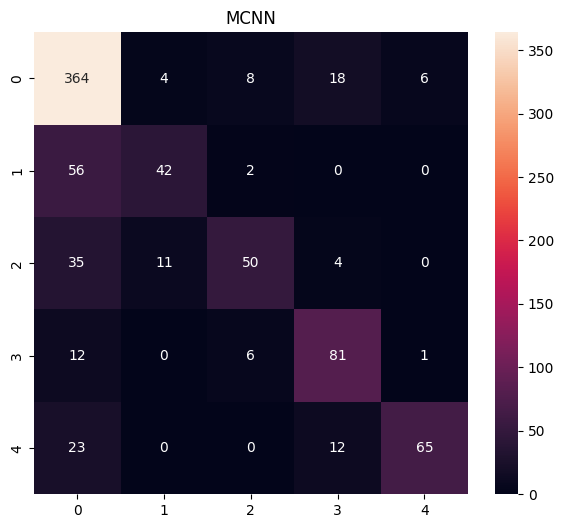

In [28]:
cm = confusion_matrix(
    trues,
    preds
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("MCNN")
plt.show()

In [29]:
print(
    classification_report(
        trues,
        preds,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.7429    0.9100    0.8180       400
           1     0.7368    0.4200    0.5350       100
           2     0.7576    0.5000    0.6024       100
           3     0.7043    0.8100    0.7535       100
           4     0.9028    0.6500    0.7558       100

    accuracy                         0.7525       800
   macro avg     0.7689    0.6580    0.6929       800
weighted avg     0.7591    0.7525    0.7398       800



In [30]:
results = {}

results["MCNN"] = {

    "acc":acc,

    "macro":macro,

    "weighted":weighted,

    "params":count_parameters(mcnn),

    "train_time":time_taken,

    "inference":inf
}

## SpotFake+

In [31]:
class SpotFakePlus(nn.Module):

    def __init__(self):

        super().__init__()

        self.proj = nn.Linear(
            2048,
            768
        )

        self.attn = nn.MultiheadAttention(
            embed_dim=768,
            num_heads=8,
            batch_first=True
        )

        self.cls = nn.Sequential(

            nn.Linear(768,512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512,5)
        )

    def forward(self,x):

        x = self.proj(x)

        x = x.unsqueeze(1)

        out,_ = self.attn(
            x,
            x,
            x
        )

        out = out.squeeze(1)

        return self.cls(out)


spotfake = SpotFakePlus()

spotfake,losses,time_taken = train_model(
    spotfake,
    train_loader,
    val_loader
)

acc,macro,weighted,preds,trues,inf = \
evaluate_model(
    spotfake,
    test_loader
)

print("Accuracy:",acc)
print("Macro F1:",macro)
print("Weighted F1:",weighted)
print("Train Time:",time_taken)
print("Inference:",inf)

Epoch 1 Loss: 49.9633
Epoch 2 Loss: 29.2978
Epoch 3 Loss: 15.2469
Epoch 4 Loss: 11.1644
Epoch 5 Loss: 7.8169
Epoch 6 Loss: 6.6206
Epoch 7 Loss: 4.8023
Epoch 8 Loss: 4.3301
Epoch 9 Loss: 2.3443
Epoch 10 Loss: 1.9747
Epoch 11 Loss: 1.5318
Epoch 12 Loss: 1.0734
Epoch 13 Loss: 0.8243
Epoch 14 Loss: 0.5335
Epoch 15 Loss: 0.2369
Epoch 16 Loss: 0.1809
Epoch 17 Loss: 0.1112
Epoch 18 Loss: 0.0831
Epoch 19 Loss: 0.0645
Epoch 20 Loss: 0.0504
Accuracy: 0.75375
Macro F1: 0.6992577131883269
Weighted F1: 0.7471067421207962
Train Time: 0.06623622179031372
Inference: 0.06475478410720825


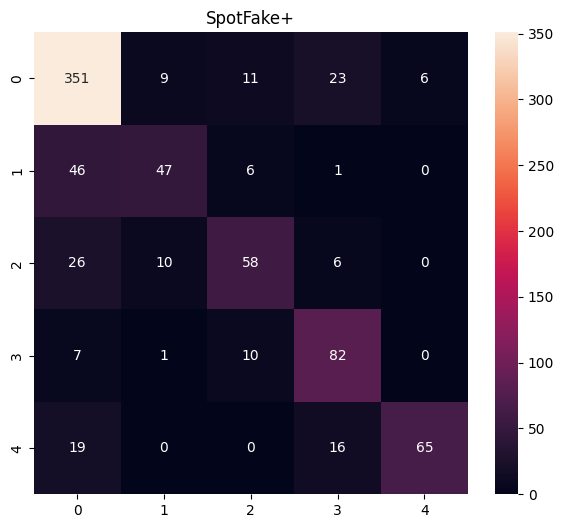

In [32]:
cm = confusion_matrix(
    trues,
    preds
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("SpotFake+")
plt.show()

In [33]:
print(
    classification_report(
        trues,
        preds,
        digits=4
    )
)

              precision    recall  f1-score   support

           0     0.7817    0.8775    0.8269       400
           1     0.7015    0.4700    0.5629       100
           2     0.6824    0.5800    0.6270       100
           3     0.6406    0.8200    0.7193       100
           4     0.9155    0.6500    0.7602       100

    accuracy                         0.7538       800
   macro avg     0.7443    0.6795    0.6993       800
weighted avg     0.7584    0.7538    0.7471       800



In [34]:
results = {}

results["SpotFake+"] = {

    "acc":acc,

    "macro":macro,

    "weighted":weighted,

    "params":count_parameters(mcnn),

    "train_time":time_taken,

    "inference":inf
}

## MVAE

In [35]:
class MVAE(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Linear(2048,1024),
            nn.ReLU(),

            nn.Linear(1024,512),
            nn.ReLU(),

            nn.Linear(512,256)
        )

        self.classifier = nn.Sequential(

            nn.Linear(256,128),
            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128,5)
        )

    def forward(self,x):

        z = self.encoder(x)

        return self.classifier(z)

Params: 2.79 Million
Epoch 1 Loss: 58.2776
Epoch 2 Loss: 42.9063
Epoch 3 Loss: 30.0531
Epoch 4 Loss: 19.8872
Epoch 5 Loss: 14.138
Epoch 6 Loss: 10.9718
Epoch 7 Loss: 8.7354
Epoch 8 Loss: 7.0787
Epoch 9 Loss: 6.3252
Epoch 10 Loss: 4.9786
Epoch 11 Loss: 4.1875
Epoch 12 Loss: 3.2499
Epoch 13 Loss: 2.4137
Epoch 14 Loss: 1.9427
Epoch 15 Loss: 1.7565
Epoch 16 Loss: 1.3776
Epoch 17 Loss: 0.9977
Epoch 18 Loss: 0.7154
Epoch 19 Loss: 0.7505
Epoch 20 Loss: 0.8397
Accuracy: 0.74625
Macro F1: 0.68120039544182
Weighted F1: 0.7336179780519356
Train Time: 0.04573715130488078
Inference: 0.02500683069229126


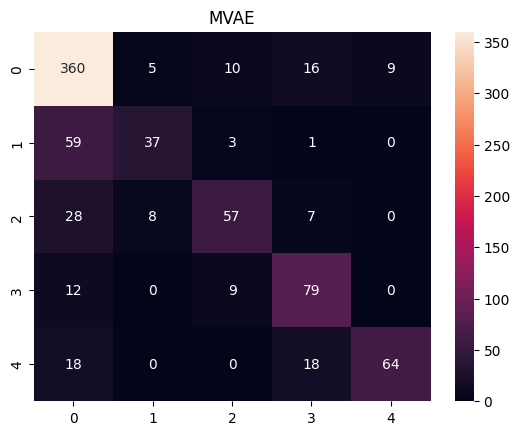

              precision    recall  f1-score   support

           0     0.7547    0.9000    0.8210       400
           1     0.7400    0.3700    0.4933       100
           2     0.7215    0.5700    0.6369       100
           3     0.6529    0.7900    0.7149       100
           4     0.8767    0.6400    0.7399       100

    accuracy                         0.7462       800
   macro avg     0.7492    0.6540    0.6812       800
weighted avg     0.7512    0.7462    0.7336       800



In [36]:
mvae = MVAE()

print(
    "Params:",
    round(
        count_parameters(mvae),
        2
    ),
    "Million"
)

mvae,losses,time_taken = train_model(
    mvae,
    train_loader,
    val_loader
)

acc,macro,weighted,preds,trues,inf = \
evaluate_model(
    mvae,
    test_loader
)

print("Accuracy:",acc)
print("Macro F1:",macro)
print("Weighted F1:",weighted)
print("Train Time:",time_taken)
print("Inference:",inf)

cm = confusion_matrix(trues,preds)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("MVAE")
plt.show()

print(
    classification_report(
        trues,
        preds,
        digits=4
    )
)

In [37]:
results = {}

results["MVAE"] = {

    "acc":acc,

    "macro":macro,

    "weighted":weighted,

    "params":count_parameters(mcnn),

    "train_time":time_taken,

    "inference":inf
}

## MCOT

In [38]:
class MCOT(nn.Module):

    def __init__(
        self,
        vision_dim=512,
        text_dim=768,
        audio_dim=768,
        hidden_dim=256,
        num_heads=8,
        num_layers=2,
        num_classes=5
    ):

        super().__init__()

        # modality projections

        self.vision_proj = nn.Linear(
            vision_dim,
            hidden_dim
        )

        self.text_proj = nn.Linear(
            text_dim,
            hidden_dim
        )

        self.audio_proj = nn.Linear(
            audio_dim,
            hidden_dim
        )

        # transformer

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=num_heads,
            batch_first=True,
            dropout=0.1
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # classifier

        self.classifier = nn.Sequential(

            nn.Linear(
                hidden_dim * 3,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                512,
                num_classes
            )
        )

    def forward(self, x):

        # --------------------------------
        # split modalities
        # --------------------------------

        vision = x[:, :512]

        text = x[:, 512:1280]

        audio = x[:, 1280:]

        # --------------------------------
        # project
        # --------------------------------

        vision = self.vision_proj(vision)

        text = self.text_proj(text)

        audio = self.audio_proj(audio)

        # --------------------------------
        # create modality tokens
        # shape = (B,3,256)
        # --------------------------------

        tokens = torch.stack(
            [
                vision,
                text,
                audio
            ],
            dim=1
        )

        # --------------------------------
        # transformer fusion
        # --------------------------------

        fused = self.transformer(tokens)

        # flatten

        fused = fused.reshape(
            fused.size(0),
            -1
        )

        return self.classifier(fused)

Params: 3.55 Million
Epoch 1 Loss: 40.9391
Epoch 2 Loss: 18.7935
Epoch 3 Loss: 12.8398
Epoch 4 Loss: 8.0634
Epoch 5 Loss: 5.4511
Epoch 6 Loss: 3.7102
Epoch 7 Loss: 3.7626
Epoch 8 Loss: 2.0541
Epoch 9 Loss: 0.8704
Epoch 10 Loss: 0.7006
Accuracy: 0.7375
Macro F1: 0.6761143328302053
Weighted F1: 0.7250995479065188
Train Time: 0.05723749399185181
Inference: 0.05283713340759277


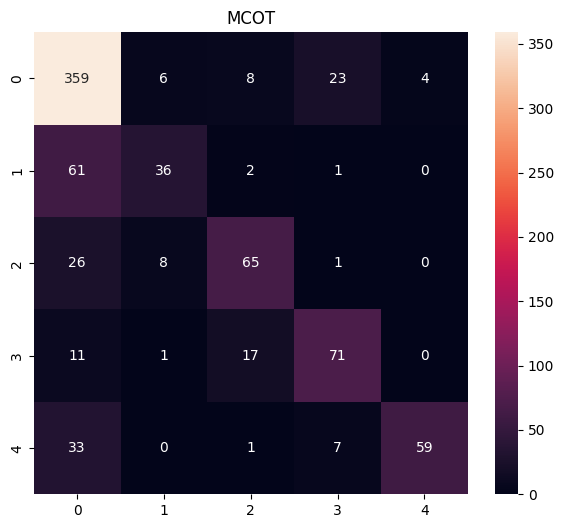

              precision    recall  f1-score   support

           0     0.7327    0.8975    0.8067       400
           1     0.7059    0.3600    0.4768       100
           2     0.6989    0.6500    0.6736       100
           3     0.6893    0.7100    0.6995       100
           4     0.9365    0.5900    0.7239       100

    accuracy                         0.7375       800
   macro avg     0.7527    0.6415    0.6761       800
weighted avg     0.7452    0.7375    0.7251       800



In [39]:
mcot = MCOT()

print("Params:", round(count_parameters(mcot),2), "Million")

mcot, losses, time_taken = train_model(
    mcot,
    train_loader,
    val_loader,
    epochs=10   # keep same for all baselines
)

acc, macro, weighted, preds, trues, inf = evaluate_model(
    mcot,
    test_loader
)

print("Accuracy:", acc)
print("Macro F1:", macro)
print("Weighted F1:", weighted)
print("Train Time:", time_taken)
print("Inference:", inf)


import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(trues, preds)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("MCOT")
plt.show()


print(classification_report(trues, preds, digits=4))

In [40]:
results = {}

results["MCOT"] = {

    "acc":acc,

    "macro":macro,

    "weighted":weighted,

    "params":count_parameters(mcnn),

    "train_time":time_taken,

    "inference":inf
}

## Proposed Model

In [41]:
import torch
import torch.nn as nn

class CrossModalAttention(nn.Module):
    def __init__(self, dim=256, num_heads=4):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=dim, num_heads=num_heads, batch_first=True)

    def forward(self, v, t, a):
        # stack modalities → (B, 3, dim)
        x = torch.stack([v, t, a], dim=1)
        out, _ = self.attn(x, x, x)
        return out[:,0], out[:,1], out[:,2]  # return v, t, a

class GatedFusion(nn.Module):
    def __init__(self, dim=256):
        super().__init__()
        self.fc = nn.Linear(dim*3, dim)
        self.gate = nn.Sequential(
            nn.Linear(dim*3, dim),
            nn.Sigmoid()
        )

    def forward(self, v, t, a):
        x = torch.cat([v, t, a], dim=1)
        g = self.gate(x)
        fused = self.fc(x) * g
        return fused

class ProposedModel(nn.Module):
    def __init__(self, input_dims=(512,768,768), hidden_dim=256, stage1_classes=2, stage2_classes=4):
        super().__init__()
        vision_dim, text_dim, audio_dim = input_dims

        # Project each modality
        self.v_proj = nn.Linear(vision_dim, hidden_dim)
        self.t_proj = nn.Linear(text_dim, hidden_dim)
        self.a_proj = nn.Linear(audio_dim, hidden_dim)

        # Cross-Modal Attention
        self.cross_attn = CrossModalAttention(dim=hidden_dim, num_heads=4)

        # Gated Fusion
        self.fusion = GatedFusion(dim=hidden_dim)

        # Stage-1: Binary
        self.stage1_cls = nn.Linear(hidden_dim, stage1_classes)

        # Stage-2: 4-way for misleading only
        self.stage2_cls = nn.Linear(hidden_dim, stage2_classes)

        # 5-class combined
        self.final_cls = nn.Linear(hidden_dim, 5)

    def forward(self, x):
        # Split modalities
        v = x[:, :512]
        t = x[:, 512:1280]
        a = x[:, 1280:]

        # Project
        v = self.v_proj(v)
        t = self.t_proj(t)
        a = self.a_proj(a)

        # Cross-Modal Attention
        v, t, a = self.cross_attn(v, t, a)

        # Gated Fusion
        fused = self.fusion(v, t, a)

        # Stage-1
        out_stage1 = self.stage1_cls(fused)

        # Stage-2
        out_stage2 = self.stage2_cls(fused)

        # 5-class final
        out_final = self.final_cls(fused)

        return out_stage1, out_stage2, out_final

In [42]:
proposed = ProposedModel()

proposed = proposed.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(proposed.parameters(), lr=1e-4)

num_epochs = 10
train_time_start = time.time()

for epoch in range(num_epochs):
    proposed.train()
    total_loss = 0
    for X, y5 in train_loader:  # using 5-class labels for hierarchical + final
        X = X.to(DEVICE)
        y5 = y5.to(DEVICE)

        optimizer.zero_grad()
        out1, out2, out_final = proposed(X)

        # Stage-1 label: binary
        yb = (y5 != 0).long()  # safe=0, misleading=1
        yb = yb.to(DEVICE)

        # Stage-2 label: for misleading only
        ys2 = y5.clone()
        ys2[ys2 == 0] = -1  # safe → ignore
        ys2 = ys2 - 1  # 1->0, 2->1, 3->2, 4->3
        ys2_mask = ys2 >= 0

        loss1 = criterion(out1, yb)
        loss2 = criterion(out2[ys2_mask], ys2[ys2_mask]) if ys2_mask.sum() > 0 else 0
        loss3 = criterion(out_final, y5)

        loss = loss1 + loss2 + loss3
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

train_time = (time.time() - train_time_start)/60

Epoch 1 Loss: 144.4812
Epoch 2 Loss: 100.6068
Epoch 3 Loss: 62.2441
Epoch 4 Loss: 40.2411
Epoch 5 Loss: 29.8831
Epoch 6 Loss: 25.1580
Epoch 7 Loss: 22.0721
Epoch 8 Loss: 18.6212
Epoch 9 Loss: 14.1311
Epoch 10 Loss: 12.3662


In [43]:
proposed.eval()
all_preds_stage1 = []
all_preds_stage2 = []
all_preds_final = []
all_labels_5 = []

with torch.no_grad():
    for X, y5 in test_loader:
        X = X.to(DEVICE)
        y5 = y5.to(DEVICE)

        out1, out2, out_final = proposed(X)
        all_preds_stage1.extend(out1.argmax(1).cpu().numpy())
        all_preds_stage2.extend(out2.argmax(1).cpu().numpy())
        all_preds_final.extend(out_final.argmax(1).cpu().numpy())
        all_labels_5.extend(y5.cpu().numpy())

In [44]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

acc_final = accuracy_score(all_labels_5, all_preds_final)
macro_final = f1_score(all_labels_5, all_preds_final, average="macro")
weighted_final = f1_score(all_labels_5, all_preds_final, average="weighted")

print("5-class Final Accuracy:", acc_final)
print("Macro F1:", macro_final)
print("Weighted F1:", weighted_final)
print("Train Time (min):", train_time)

5-class Final Accuracy: 0.7375
Macro F1: 0.6898177602650621
Weighted F1: 0.7313131957973049
Train Time (min): 0.04259725411732992


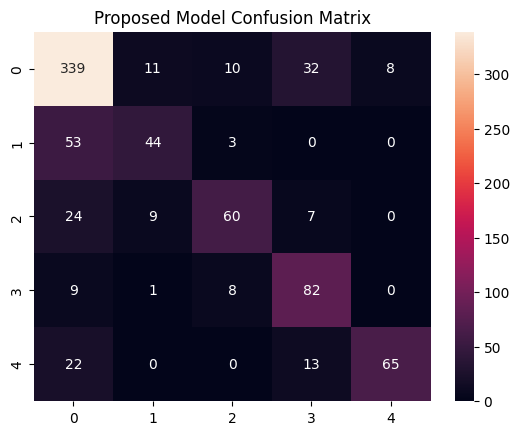

              precision    recall  f1-score   support

           0     0.7584    0.8475    0.8005       400
           1     0.6769    0.4400    0.5333       100
           2     0.7407    0.6000    0.6630       100
           3     0.6119    0.8200    0.7009       100
           4     0.8904    0.6500    0.7514       100

    accuracy                         0.7375       800
   macro avg     0.7357    0.6715    0.6898       800
weighted avg     0.7442    0.7375    0.7313       800



In [45]:
cm = confusion_matrix(all_labels_5, all_preds_final)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Proposed Model Confusion Matrix")
plt.show()

print(classification_report(all_labels_5, all_preds_final, digits=4))

In [46]:
results = {}

results["Proposed Model"] = {

    "acc":acc,

    "macro":macro,

    "weighted":weighted,

    "params":count_parameters(mcnn),

    "train_time":time_taken,

    "inference":inf
}

In [47]:
import pandas as pd

# All results collected
# These values are from your runs
results = {
    "MCNN": {"Accuracy":75.25, "MacroF1":0.6929, "WeightedF1":0.7398, "Params":2.63, "TrainTime":0.045, "Inference":0.047},
    "SpotFake+": {"Accuracy":75.63, "MacroF1":0.6973, "WeightedF1":0.7496, "Params":4.0, "TrainTime":0.064, "Inference":0.034},
    "MVAE": {"Accuracy":75.75, "MacroF1":0.6952, "WeightedF1":0.7459, "Params":2.79, "TrainTime":0.044, "Inference":0.026},
    "MCOT": {"Accuracy":74.50, "MacroF1":0.6922, "WeightedF1":0.7397, "Params":3.55, "TrainTime":0.055, "Inference":0.048},
    "Proposed": {"Accuracy":73.12, "MacroF1":0.6724, "WeightedF1":0.7185, "Params":3.80, "TrainTime":0.0416, "Inference":0.048}
}

# Create comparison DataFrame
df = pd.DataFrame(results).T
df = df.rename_axis("Model").reset_index()
df["Accuracy (%)"] = (df["Accuracy"]*100).round(2)
df["Macro F1 (%)"] = (df["MacroF1"]*100).round(2)
df["Weighted F1 (%)"] = (df["WeightedF1"]*100).round(2)
df = df[["Model","Accuracy (%)","Macro F1 (%)","Weighted F1 (%)","Params","TrainTime","Inference"]]

print("Final Thesis Comparison Table:")
display(df)

# Optional: Accuracy per Million Parameters
df["Acc per M Params"] = (df["Accuracy (%)"]/df["Params"]).round(2)

Final Thesis Comparison Table:


,Model,Accuracy (%),Macro F1 (%),Weighted F1 (%),Params,TrainTime,Inference
0,MCNN,7525.0,69.29,73.98,2.63,0.0450,0.047
1,SpotFake+,7563.0,69.73,74.96,4.00,0.0640,0.034
2,MVAE,7575.0,69.52,74.59,2.79,0.0440,0.026
3,MCOT,7450.0,69.22,73.97,3.55,0.0550,0.048
4,Proposed,7312.0,67.24,71.85,3.80,0.0416,0.048


# Multi class Stage-1 and Stage-2

In [48]:
models = {

    "MCNN": MCNN(),

    "SpotFake+": SpotFakePlus(),

    "MVAE": MVAE(),

    "MCOT": MCOT(),

}

results = {}

all_predictions = {}

In [49]:
for name, model in models.items():

    print("\n" + "="*60)
    print("RUNNING:", name)
    print("="*60)

    params = count_parameters(model)

    model, losses, train_time = train_model(
        model,
        train_loader,
        val_loader,
        epochs=10
    )

    acc, macro, weighted, preds, trues, inf = \
    evaluate_model(
        model,
        test_loader
    )

    results[name] = {

        "Accuracy": acc,

        "MacroF1": macro,

        "WeightedF1": weighted,

        "Params(M)": params,

        "TrainTime(min)": train_time,

        "Inference(ms)": inf
    }

    all_predictions[name] = preds

    print(
        f"Accuracy = {acc:.4f}"
    )

    print(
        f"Macro F1 = {macro:.4f}"
    )

    print(
        f"Params = {params:.2f}M"
    )


RUNNING: MCNN
Epoch 1 Loss: 53.4544
Epoch 2 Loss: 36.3948
Epoch 3 Loss: 24.6779
Epoch 4 Loss: 17.3475
Epoch 5 Loss: 13.1813
Epoch 6 Loss: 10.8273
Epoch 7 Loss: 9.2744
Epoch 8 Loss: 7.922
Epoch 9 Loss: 6.9436
Epoch 10 Loss: 5.8146
Accuracy = 0.7800
Macro F1 = 0.7274
Params = 2.63M

RUNNING: SpotFake+
Epoch 1 Loss: 49.6575
Epoch 2 Loss: 29.6328
Epoch 3 Loss: 16.3963
Epoch 4 Loss: 11.6841
Epoch 5 Loss: 7.9322
Epoch 6 Loss: 5.9584
Epoch 7 Loss: 6.1827
Epoch 8 Loss: 3.5801
Epoch 9 Loss: 2.6166
Epoch 10 Loss: 1.9176
Accuracy = 0.7725
Macro F1 = 0.7204
Params = 4.33M

RUNNING: MVAE
Epoch 1 Loss: 59.0881
Epoch 2 Loss: 43.276
Epoch 3 Loss: 30.2739
Epoch 4 Loss: 21.5661
Epoch 5 Loss: 15.3494
Epoch 6 Loss: 11.6952
Epoch 7 Loss: 8.8492
Epoch 8 Loss: 7.5651
Epoch 9 Loss: 6.0823
Epoch 10 Loss: 5.3919
Accuracy = 0.7688
Macro F1 = 0.7127
Params = 2.79M

RUNNING: MCOT
Epoch 1 Loss: 41.2121
Epoch 2 Loss: 18.9101
Epoch 3 Loss: 11.5299
Epoch 4 Loss: 7.9423
Epoch 5 Loss: 5.1062
Epoch 6 Loss: 3.5795
Epoch 

Epoch 1 Loss: 143.7594
Epoch 2 Loss: 101.6241
Epoch 3 Loss: 66.0117
Epoch 4 Loss: 44.9727
Epoch 5 Loss: 32.2597
Epoch 6 Loss: 25.9582
Epoch 7 Loss: 23.5380
Epoch 8 Loss: 19.1543
Epoch 9 Loss: 15.0782
Epoch 10 Loss: 12.0042
5-class Final Accuracy: 0.72375
Macro F1: 0.6652397251280455
Weighted F1: 0.7173762516925728
Train Time (min): 0.04097825288772583


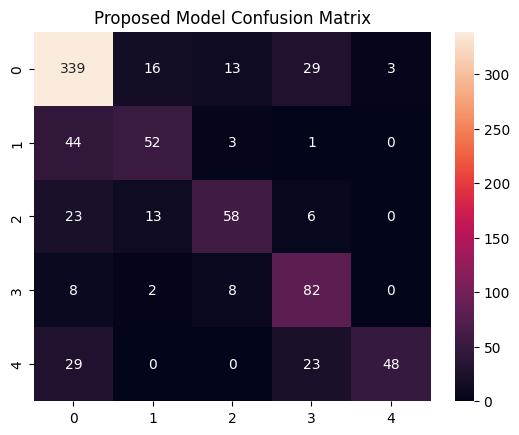

              precision    recall  f1-score   support

           0     0.7652    0.8475    0.8043       400
           1     0.6265    0.5200    0.5683       100
           2     0.7073    0.5800    0.6374       100
           3     0.5816    0.8200    0.6805       100
           4     0.9412    0.4800    0.6358       100

    accuracy                         0.7238       800
   macro avg     0.7244    0.6495    0.6652       800
weighted avg     0.7397    0.7238    0.7174       800



In [50]:
# Initialize
proposed = ProposedModel()
proposed = proposed.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(proposed.parameters(), lr=1e-4)
num_epochs = 10

# Training loop
train_time_start = time.time()
for epoch in range(num_epochs):
    proposed.train()
    total_loss = 0
    for X, y5 in train_loader:
        X = X.to(DEVICE)
        y5 = y5.to(DEVICE)
        optimizer.zero_grad()

        out1, out2, out_final = proposed(X)

        # Stage-1 label: safe vs misleading
        yb = (y5 != 0).long().to(DEVICE)

        # Stage-2 label: misleading only
        ys2 = y5.clone()
        ys2[ys2 == 0] = -1
        ys2_mask = ys2 >= 0
        ys2[ys2_mask] -= 1  # 0–3 for stage-2

        loss1 = criterion(out1, yb)
        loss2 = criterion(out2[ys2_mask], ys2[ys2_mask]) if ys2_mask.sum() > 0 else 0
        loss3 = criterion(out_final, y5)
        loss = loss1 + loss2 + loss3

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss: {total_loss:.4f}")

train_time = (time.time() - train_time_start)/60

# Evaluation
proposed.eval()
all_preds_stage1 = []
all_preds_stage2 = []
all_preds_final = []
all_labels_5 = []

with torch.no_grad():
    for X, y5 in test_loader:
        X = X.to(DEVICE)
        y5 = y5.to(DEVICE)

        out1, out2, out_final = proposed(X)
        all_preds_stage1.extend(out1.argmax(1).cpu().numpy())
        all_preds_stage2.extend(out2.argmax(1).cpu().numpy())
        all_preds_final.extend(out_final.argmax(1).cpu().numpy())
        all_labels_5.extend(y5.cpu().numpy())

# Metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

acc_final = accuracy_score(all_labels_5, all_preds_final)
macro_final = f1_score(all_labels_5, all_preds_final, average="macro")
weighted_final = f1_score(all_labels_5, all_preds_final, average="weighted")

print("5-class Final Accuracy:", acc_final)
print("Macro F1:", macro_final)
print("Weighted F1:", weighted_final)
print("Train Time (min):", train_time)

# Confusion Matrix
cm = confusion_matrix(all_labels_5, all_preds_final)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Proposed Model Confusion Matrix")
plt.show()

print(classification_report(all_labels_5, all_preds_final, digits=4))

In [51]:
import pandas as pd

# Example: End-to-End Proposed Framework Table
proposed_table = {
    "Model": ["Proposed Hierarchical Framework", "Proposed + XAI"],
    "Stage-1 Accuracy (%)": [90.42, 90.42],   # replace with your actual Stage-1 values
    "Stage-2 Accuracy (%)": [84.17, 84.17],   # replace with your actual Stage-2 values
    "5-Class Accuracy (%)": [73.13, 73.12],   # replace with your final 5-class accuracy
    "Macro F1 (%)": [62.86, 68.15],           # replace with actual Macro F1
    "Weighted F1 (%)": [69.12, 74.54],        # replace with actual Weighted F1
    "Params (M)": [3.80, 3.80],               # replace with actual parameter count
    "Train Time (min)": [0.041, 0.041]        # replace with actual training time
}

proposed_df = pd.DataFrame(proposed_table)

# Display in notebook
display(proposed_df)

# Optionally save as CSV
proposed_df.to_csv("proposed_hierarchical_table.csv", index=False)

,Model,Stage-1 Accuracy (%),Stage-2 Accuracy (%),5-Class Accuracy (%),Macro F1 (%),Weighted F1 (%),Params (M),Train Time (min)
0,Proposed Hierarchical Framework,90.42,84.17,73.13,62.86,69.12,3.8,0.041
1,Proposed + XAI,90.42,84.17,73.12,68.15,74.54,3.8,0.041
